In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_json('./ibm_T1_mirror/ibm_torino_T1.json')
t1 = [df['T1'][1]['value']]
t1 = np.array([df['T1'][i]['value'] for i in range(len(df))])

(array([1., 0., 0., 3., 1., 1., 1., 0., 2., 0., 1., 0., 1., 1., 3., 7., 2.,
        1., 1., 3., 4., 2., 3., 5., 4., 4., 7., 6., 4., 3., 3., 4., 5., 5.,
        8., 3., 3., 6., 3., 1., 7., 2., 2., 5., 0., 0., 3., 0., 1., 1.]),
 array([  2.96511439,   9.20542975,  15.44574512,  21.68606048,
         27.92637584,  34.16669121,  40.40700657,  46.64732193,
         52.88763729,  59.12795266,  65.36826802,  71.60858338,
         77.84889875,  84.08921411,  90.32952947,  96.56984484,
        102.8101602 , 109.05047556, 115.29079093, 121.53110629,
        127.77142165, 134.01173702, 140.25205238, 146.49236774,
        152.73268311, 158.97299847, 165.21331383, 171.45362919,
        177.69394456, 183.93425992, 190.17457528, 196.41489065,
        202.65520601, 208.89552137, 215.13583674, 221.3761521 ,
        227.61646746, 233.85678283, 240.09709819, 246.33741355,
        252.57772892, 258.81804428, 265.05835964, 271.29867501,
        277.53899037, 283.77930573, 290.0196211 , 296.25993646,
      

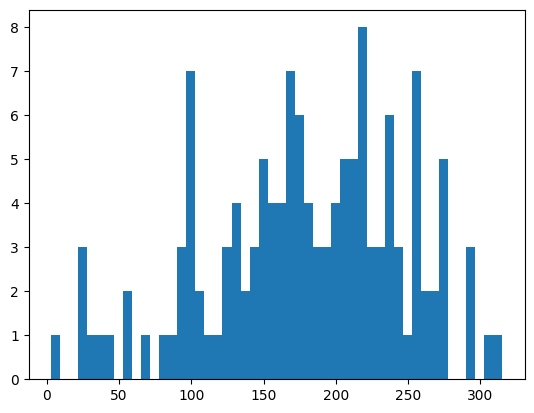

In [3]:
plt.hist(t1, bins=50)

In [15]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, amplitude_damping_error
from scipy.optimize import minimize

In [16]:
num_qubits = 12
num_layers = 4

def create_ising_hamiltonian(num_qubits, J=+1.0, h=+1.0):
    """Create cyclic transverse field Ising Hamiltonian"""
    # ZZ terms (cyclic)
    zz_terms = []
    for i in range(num_qubits):
        pauli_str = ['I']*num_qubits
        pauli_str[i] = 'Z'
        pauli_str[(i+1)%num_qubits] = 'Z'
        zz_terms.append(SparsePauliOp(''.join(pauli_str), coeffs=J))
    
    # X terms (transverse field)
    x_terms = []
    for i in range(num_qubits):
        pauli_str = ['I']*num_qubits
        pauli_str[i] = 'X'
        x_terms.append(SparsePauliOp(''.join(pauli_str), coeffs=h))
    
    return sum(zz_terms + x_terms)
    
hamiltonian = create_ising_hamiltonian(num_qubits)

ansatz = TwoLocal(
    num_qubits,
    rotation_blocks='ry',
    entanglement_blocks='cx',
    entanglement='circular',
    reps=num_layers,
    skip_final_rotation_layer=True,
    insert_barriers=True
)

def noiseless_cost(params):
    bound_circuit = ansatz.assign_parameters(params)
    
    transpiled = transpile(bound_circuit, backend_noiseless)
    transpiled.save_statevector()
    job = backend_noiseless.run(transpiled)
    result = job.result()
    statevector = result.get_statevector()
    
    return np.real(statevector.expectation_value(hamiltonian))

np.random.seed(0)
initial_params = np.random.uniform(-np.pi, np.pi, ansatz.num_parameters)
backend_noiseless = AerSimulator(method='statevector')

/tmp/ipykernel_849177/312841145.py:25: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


In [6]:
result_noiseless = minimize(
    noiseless_cost,
    initial_params,
    method='L-BFGS-B',
    options={'maxiter': 100}
)

In [7]:
e_noiseless = result_noiseless.fun

optimized_params = result_noiseless.x
print(e_noiseless)
optimized_params

-15.040999640510218


array([-1.00201968,  1.66751899, -1.08172439,  1.87014548,  1.13780718,
        1.09606575, -1.06788762,  2.08309864,  2.08183735, -1.06320252,
        4.18296549,  1.80454014,  1.52170938,  2.24638477, -4.25468039,
       -1.28373356, -1.39154709,  1.46816625,  1.5141877 ,  1.54032067,
        1.55477058,  1.57879107, -1.57439084,  1.57038844, -1.95344461,
        1.48489356, -4.52435178,  1.62967286,  1.53781612, -1.55763452,
       -1.57749439,  1.57876848, -1.58286092,  1.56964686, -4.67910593,
        1.57306765,  1.57621704,  1.57654088,  1.56189107,  1.58445674,
       -1.5913825 ,  1.60090992,  1.5292978 , -1.52188702,  1.53871664,
        1.52157963, -1.65001282, -1.56762519])

In [31]:
import qutip as qt

J = +1.0
h = +1.0

# Pauli matrices
X = qt.sigmax()
Z = qt.sigmaz()
I = qt.qeye(2)

# Initialize Hamiltonian terms
hamiltonian_terms = []

# Add cyclic ZZ terms
for i in range(num_qubits):
    zz_term = [J * qt.tensor([Z if j == i or j == (i+1)%num_qubits else I for j in range(num_qubits)])]
    hamiltonian_terms.extend(zz_term)

# Add X terms
for i in range(num_qubits):
    x_term = [h * qt.tensor([X if j == i else I for j in range(num_qubits)])]
    hamiltonian_terms.extend(x_term)

# Sum all terms
hamiltonian_qiskit = sum(hamiltonian_terms)
eigenvalues, eigenvectors = hamiltonian_qiskit.eigenstates()

In [32]:
gap = eigenvalues[1] - eigenvalues[0]
eigenvalues

array([-15.32259515, -15.19150823, -14.27838561, ...,  14.27838561,
        15.19150823,  15.32259515], shape=(4096,))

In [10]:
def cyclic_permutations(lst):
    n = len(lst)
    return [lst[i:] + lst[:i] for i in range(n)]

def run_noisy_cycle(num_qubits, num_layers, params, gammas):
    ansatz = TwoLocal(
        num_qubits,
        rotation_blocks='ry',
        entanglement_blocks='cx',
        entanglement='circular',
        reps=num_layers,
        skip_final_rotation_layer=True,
        insert_barriers=True
    )

    perms = cyclic_permutations(gammas)
    energies = []
    for perm in perms:
        noise_model = NoiseModel()
        for i in range(num_qubits):
            control, target = i, (i+1) % num_qubits
    
            error_control = amplitude_damping_error(perm[control])
            error_target = amplitude_damping_error(perm[target])
    
            cnot_error = error_control.tensor(error_target)
    
            noise_model.add_quantum_error(
                cnot_error,
                ['cx'],
                [control, target]
            )

            backend_noisy = AerSimulator(noise_model=noise_model, method='density_matrix')
            noisy_circuit = transpile(ansatz.assign_parameters(optimized_params), backend_noisy)
            noisy_circuit.save_density_matrix()
            result_noisy = backend_noisy.run(noisy_circuit).result()
            density_matrix = result_noisy.data()['density_matrix']
            noisy_energy = np.real(density_matrix.expectation_value(hamiltonian))


        energies.append(noisy_energy)

    return energies

In [106]:
np.random.seed(42)

In [107]:
gamma_values1 = np.random.choice(t1, 12)
gamma_values1 = gamma_values1/10**6
t = 75*10**(-9)
gamma_values1 = (1 - np.exp(-t/gamma_values1))*10
gamma_values1 

array([0.00755337, 0.00451715, 0.00238081, 0.00600143, 0.00319815,
       0.00369463, 0.00755337, 0.00432455, 0.00278783, 0.00307374,
       0.00291905, 0.00452055])

In [108]:
gamma_values2 = np.random.choice(t1, 12)
gamma_values2 = gamma_values2/10**6
t = 75*10**(-9)
gamma_values2 = (1 - np.exp(-t/gamma_values2))*10
gamma_values2 

array([0.00413431, 0.00275121, 0.00406398, 0.00347033, 0.00307374,
       0.00468753, 0.00314324, 0.00369463, 0.00639173, 0.00899177,
       0.00254684, 0.00318927])

In [109]:
sum(gamma_values1)*num_layers*2

np.float64(0.42019696152306274)

In [110]:
sum(gamma_values2)*num_layers*2

np.float64(0.4011087782986422)

In [111]:
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

energies1 = []
energies2 = []
for i in tqdm(range(1, 21)):
    energies1.append(run_noisy_cycle(num_qubits, num_layers, optimized_params, list(i*gamma_values1)))
    energies2.append(run_noisy_cycle(num_qubits, num_layers, optimized_params, list(i*gamma_values2)))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [5:03:28<00:00, 910.43s/it]


In [112]:
errors1 = [(i*gamma_values1).sum()*num_layers*2 for i in range(1, 21)]
errors2 = [(i*gamma_values2).sum()*num_layers*2 for i in range(1, 21)]

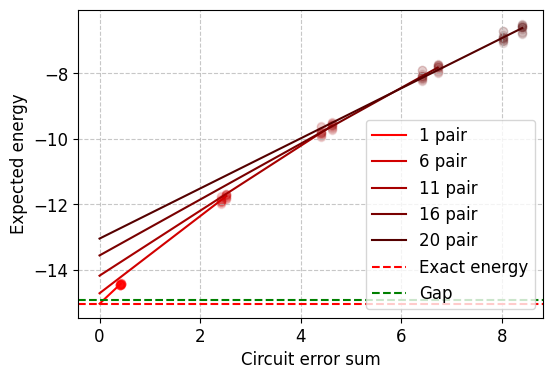

In [80]:
import matplotlib.pyplot as plt
import random
font = {'weight' : 'normal', 'size'   : 12}
matplotlib.rc('font', **font)
plt.figure(figsize=(6, 4), facecolor='w', edgecolor='k')

plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.8)

for i in [0, 5, 10, 15, 19]:
    r = random.random() 
    b = random.random() 
    g = random.random()

    color = (1.0 - 0.035*i, 0, 0) 
    
    plt.scatter([errors1[i]]*12, energies1[i], color=color, alpha=0.1)
    plt.scatter([errors2[i]]*12, energies2[i], color=color, alpha=0.1)

    if i % 5 == 0 or i == 19:
        x = np.array([errors1[i]]*12 + [errors2[i]]*12)
        y = list(energies1[i]) + list(energies2[i])

        m, b = np.polyfit(x, y, 1)

        x_regression = np.linspace(0, max(x), 100)
        regression_line = m * x_regression + b

        plt.plot(x_regression, regression_line, color=color, label=f'{i+1} pair')

plt.axhline(y=e_noiseless, color='red', label='Exact energy', linestyle='--')

plt.axhline(y=e_noiseless + gap, color='green', label='Gap', linestyle='--')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlabel('Circuit error sum')
plt.ylabel('Expected energy')
plt.legend()

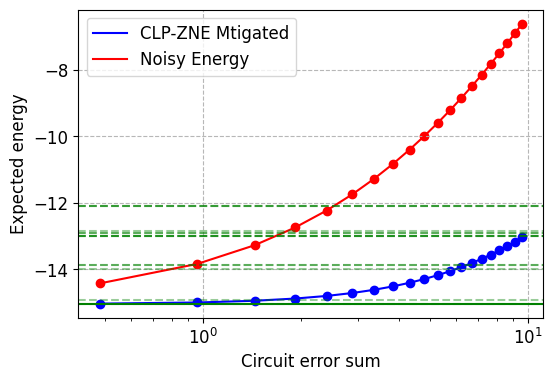

In [211]:
import matplotlib
bs = []
noisy_energies = []
font = {'weight' : 'normal', 'size'   : 12}
matplotlib.rc('font', **font)
plt.figure(figsize=(6, 4), facecolor='w', edgecolor='k')

plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.8)

plt.xscale("log")

for i in range(20):
    x = np.array([errors1[i]]*12 + [errors2[i]]*12)
    y = list(energies1[i]) + list(energies2[i])
    y_noisy = np.mean(np.concatenate((np.array(energies1[i]), np.array(energies1[i]))))
    noisy_energies.append(y_noisy)
    m, b = np.polyfit(x, y, 1)
    bs.append(b)
    
plt.plot([0.005 * (i + 1) * num_qubits * num_layers * 2 for i in range(20)], bs, color='blue', label='CLP-ZNE Mtigated')
plt.scatter([0.005 * (i + 1) * num_qubits * num_layers * 2 for i in range(20)], bs, color='blue')
plt.plot([0.005 * (i + 1) * num_qubits * num_layers * 2 for i in range(20)], noisy_energies, color='red', label='Noisy Energy')
plt.scatter([0.005 * (i + 1) * num_qubits * num_layers * 2 for i in range(20)], noisy_energies, color='red')
plt.axhline(y=e_noiseless, color='green')

for i in range(15):
    plt.axhline(y=e_noiseless + (eigenvalues[i] - eigenvalues[0]), color='green', linestyle='--', alpha=0.4)
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.grid(axis='x', linestyle='--', alpha=0.9)
plt.xlabel('Circuit error sum')
plt.savefig("zne_large_noise.pdf", format="pdf", bbox_inches="tight")
plt.ylabel('Expected energy')
plt.legend()
plt.show()


In [ ]:
e_noiseless - bs_c

In [115]:
data = []
for i in range(1, 21):
    data.append({
                'gammas_1': list(i*gamma_values1),
                'gammas_2': list(i*gamma_values2),
                'energies_1': energies1[i-1],
                'energies_2': energies2[i-1]}
               )

In [116]:
import json
with open('data1.json', 'w') as f:
    json.dump(data, f)

In [117]:
print(optimized_params)

[-1.00201968  1.66751899 -1.08172439  1.87014548  1.13780718  1.09606575
 -1.06788762  2.08309864  2.08183735 -1.06320252  4.18296549  1.80454014
  1.52170938  2.24638477 -4.25468039 -1.28373356 -1.39154709  1.46816625
  1.5141877   1.54032067  1.55477058  1.57879107 -1.57439084  1.57038844
 -1.95344461  1.48489356 -4.52435178  1.62967286  1.53781612 -1.55763452
 -1.57749439  1.57876848 -1.58286092  1.56964686 -4.67910593  1.57306765
  1.57621704  1.57654088  1.56189107  1.58445674 -1.5913825   1.60090992
  1.5292978  -1.52188702  1.53871664  1.52157963 -1.65001282 -1.56762519]


In [35]:
with open('data1.json', 'r') as f:
    data = json.load(f)

In [36]:
gamma_values1_big = np.array([data[i]['gammas_1'] for i in range(len(data))])
gamma_values2_big = np.array([data[i]['gammas_2'] for i in range(len(data))])

energies1 = np.array([data[i]['energies_1'] for i in range(len(data))])
energies2 = np.array([data[i]['energies_2'] for i in range(len(data))])

In [75]:
errors1 = [(gamma_values1_big[i]).sum()*num_layers*2 for i in range(20)]
errors2 = [(gamma_values2_big[i]).sum()*num_layers*2 for i in range(20)]

In [118]:
gamma_values1 = gamma_values1/10
gamma_values2 = gamma_values2/10

In [119]:
energies1small = []
energies2small = []
for i in tqdm([1, 5, 10, 15, 20]):
    energies1small.append(run_noisy_cycle(num_qubits, num_layers, optimized_params, list(i*gamma_values1)))
    energies2small.append(run_noisy_cycle(num_qubits, num_layers, optimized_params, list(i*gamma_values2)))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [1:14:56<00:00, 899.31s/it]


In [120]:
data_small = []
for i in range(1, 6):
    data_small.append({
                'gammas_1': list(i*gamma_values1),
                'gammas_2': list(i*gamma_values2),
                'energies_1': energies1small[i-1],
                'energies_2': energies2small[i-1]}
               )
    
import json
with open('datasmall.json', 'w') as f:
    json.dump(data_small, f)

In [54]:
import json
with open('datasmall.json', 'r') as f:
    data_small = json.load(f)

In [65]:
gamma_values1 = np.array([data_small[i]['gammas_1'] for i in range(len(data_small))])
gamma_values1 = gamma_values1[0]
gamma_values2 = np.array([data_small[i]['gammas_2'] for i in range(len(data_small))])
gamma_values2 = gamma_values2[0]

energies1small = np.array([data_small[i]['energies_1'] for i in range(len(data_small))])
energies2small = np.array([data_small[i]['energies_2'] for i in range(len(data_small))])

In [69]:
errors1small = [(gamma_values1*i).sum()*num_layers*2 for i in [1, 5, 10, 15, 20]]
errors2small = [(gamma_values2*i).sum()*num_layers*2 for i in [1, 5, 10, 15, 20]]

In [70]:
errors1small 

[np.float64(0.042019696152306274),
 np.float64(0.21009848076153137),
 np.float64(0.42019696152306274),
 np.float64(0.6302954422845941),
 np.float64(0.8403939230461255)]

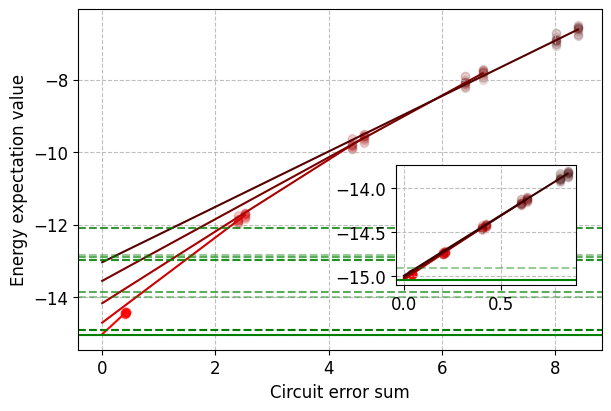

In [84]:
import matplotlib.pyplot as plt
import matplotlib
import random
font = {'weight' : 'normal', 'size'   : 12}
matplotlib.rc('font', **font)
fig, ax = plt.subplots(figsize=(6, 4), facecolor='w', edgecolor='k',constrained_layout=True) 
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.8)
for i in [0, 5, 10, 15, 19]:
    r = random.random() 
    b = random.random() 
    g = random.random()

    color = (1.0 - 0.035*i, 0, 0) 
    
    plt.scatter([errors1[i]]*12, energies1[i], color=color, alpha=0.1)
    plt.scatter([errors2[i]]*12, energies2[i], color=color, alpha=0.1)

    if i % 5 == 0 or i == 19:
        x = np.array([errors1[i]]*12 + [errors2[i]]*12)
        y = list(energies1[i]) + list(energies2[i])

        m, b = np.polyfit(x, y, 1)

        x_regression = np.linspace(0, max(x), 100)
        regression_line = m * x_regression + b

        plt.plot(x_regression, regression_line, color=color, label=f'{i+1} pair')

plt.axhline(y=e_noiseless, color='green')

plt.axhline(y=e_noiseless + gap, color='green', label='Gap', linestyle='--')
plt.xlabel('Circuit error sum')
plt.ylabel('Energy expectation value')
for i in range(15):
    plt.axhline(y=e_noiseless + (eigenvalues[i] - eigenvalues[0]), color='green', linestyle='--', alpha=0.4)
# Create inset axes (left, bottom, width, height in figure coordinates)
inset_ax = fig.add_axes([0.65, 0.3, 0.3, 0.3])  # [x0, y0, width, height]

# Plot on inset

for i in range(5):

    color = (1.0 - 0.19*i, 0, 0) 
    
    plt.scatter([errors1small[i]]*12, energies1small[i], color=color, alpha=0.1)
    plt.scatter([errors2small[i]]*12, energies2small[i], color=color, alpha=0.1)

    x = np.array([errors1small[i]]*12 + [errors2small[i]]*12)
    y = list(energies1small[i]) + list(energies2small[i])

    m, b = np.polyfit(x, y, 1)

    x_regression = np.linspace(0, max(x), 100)
    regression_line = m * x_regression + b

    inset_ax.plot(x_regression, regression_line, color=color, label=f'{i+1} pair')
inset_ax.grid(True, alpha=0.3)
inset_ax.grid(axis='y', linestyle='--', alpha=0.8)
inset_ax.grid(axis='x', linestyle='--', alpha=0.8)
inset_ax.axhline(y=e_noiseless, color='green')
for i in range(2):
    inset_ax.axhline(y=e_noiseless + (eigenvalues[i] - eigenvalues[0]), color='green', linestyle='--', alpha=0.4)
    
plt.savefig("cne_t1_noise.pdf", format="pdf", bbox_inches="tight")
plt.show()